In [8]:
import numpy as np
from datasets import Dataset
from PIL import Image
import matplotlib.pyplot as plt
import pathlib
from transformers import SamProcessor
from torch.utils.data import DataLoader
from patchify import patchify  #Only to handle large images
import os
import random
import scipy

# https://pytorch.org/docs/stable/index.html
import torch

# https://huggingface.co/docs/transformers/v4.39.3/en/index
from transformers import SamModel, SamProcessor

# pre-defined loader functions
import sys
sys.path.append(r"C:\Users\tkpp2\Documents\FISH-ML2\sam_train")
import fishLoader as fish

# # pre-defined pre-proc functions
# import pre_proc_func as ppf

In [64]:
def process_tiff_images(obj, exposure_factor=30, return_single=False):
    """
    obj can be:
      - directory path (str/Path): process all .tif/.tiff there
      - file path (str/Path): process that file
      - numpy ndarray: process that array
      - PIL.Image.Image: process that image
    """
    def _expose(arr):
        arr = np.asarray(arr)
        max_clip = 65535 if arr.dtype in (np.uint16, np.int32, np.uint32) else 255
        exposed = np.clip(arr.astype(np.float32) * exposure_factor, 0, max_clip).astype(arr.dtype)
        return exposed

    # ndarray
    if isinstance(obj, np.ndarray):
        out = [_expose(obj)]
    # PIL Image
    elif isinstance(obj, Image.Image):
        out = [_expose(np.array(obj))]
    else:
        p = pathlib.Path(obj)
        if p.is_file():
            if p.suffix.lower() not in (".tif", ".tiff"):
                raise ValueError(f"Not a TIFF: {p}")
            with Image.open(p) as im:
                                out = [_expose(np.array(im))]
        else:
            if not p.is_dir():
                raise ValueError(f"Path not found: {p}")
            tiff_paths = sorted([fp for fp in p.iterdir() if fp.suffix.lower() in (".tif", ".tiff")])
            out = []
            for fp in tiff_paths:
                with Image.open(fp) as im:
                    out.append(_expose(np.array(im)))
    if return_single and len(out) == 1:
        return out[0]
    return out

def grayscale_to_rgb(grayscale_imgs):
    # Initialize an empty array to hold the RGB images
    # The new shape will have an extra dimension for the channels at the end
    rgb_imgs = np.zeros((grayscale_imgs.shape[0], grayscale_imgs.shape[1], grayscale_imgs.shape[2], 3), dtype=np.uint8)
    
    for i in range(grayscale_imgs.shape[0]):
        # Duplicate the grayscale image data across three channels
        rgb_imgs[i] = np.stack((grayscale_imgs[i],) * 3, axis=-1)

    return rgb_imgs


In [9]:
def load_matlab_data(mat_file):
    file = pathlib.Path(mat_file)
    mat = scipy.io.loadmat(file)
    return mat

In [10]:
filename = r"C:\Users\tkpp2\Documents\FISH-ML2\assets\EXP251009COL\matlabEXP251009COL_251022_1739_all_track.mat"
mat = load_matlab_data(filename)
all_keys = mat.keys()
print("Total keys:", len(all_keys))
keys = []
for k in all_keys:
    if k.startswith("Track"):
        keys.append(k)
        print(k)

Total keys: 17
Track251009COLA01
Track251009COLA02
Track251009COLA03
Track251009COLB01
Track251009COLB02
Track251009COLB03
Track251009COLC01
Track251009COLC02
Track251009COLD01
Track251009COLD02
Track251009COLE01
Track251009COLE02
Track251009COLF01
Track251009COLF02


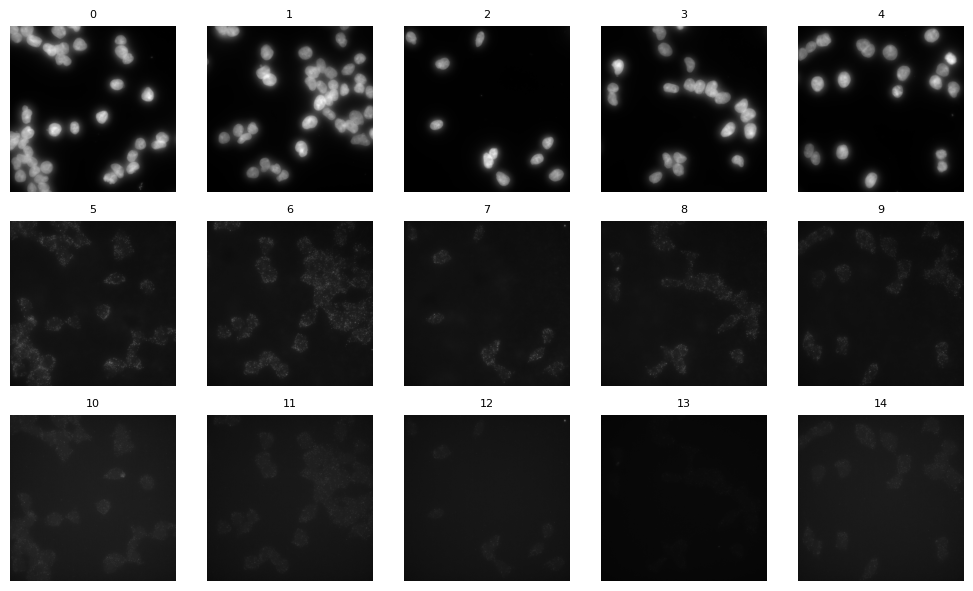

In [72]:
folder = r"C:\Users\tkpp2\Documents\FISH-ML2\assets\EXP251009COL\EXP251009COLA01"

import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
files = sorted([f for f in os.listdir(folder) if f.lower().endswith(('.tif','.tiff'))])
images = [np.array(Image.open(os.path.join(folder, f))) for f in files]

cols = 5
rows = (len(images) + cols - 1) // cols
plt.figure(figsize=(cols*2, rows*2))
for i, img in enumerate(images):
    plt.subplot(rows, cols, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(i, fontsize=8)
plt.tight_layout()
plt.show()

In [74]:
import re, os
from collections import defaultdict

sample_dict = defaultdict(dict)

pattern = re.compile(r'_w(\d+)-(DAPI|ATTO647N|AF488|AF555|AF594)_s(\d+)\.tif$', re.IGNORECASE)
dye_map = {
    "DAPI": "DAPI",
    "ATTO647N": "647",
    "AF488": "488",
    "AF555": "555",
    "AF594": "594",
}

for f in files:
    m = pattern.search(f)
    if not m:
        continue
    w_num, dye, s_id = m.groups()
    channel_key = dye_map[dye]            
    sample_key = f"s{s_id}"
    img = np.array(Image.open(os.path.join(folder, f)))
    sample_dict[sample_key][channel_key] = img

sample_dict.keys()


dict_keys(['s001', 's002', 's003', 's004', 's005'])

In [75]:
sample_dict["s001"].keys()

dict_keys(['DAPI', '647', '488'])

>u2 125 505


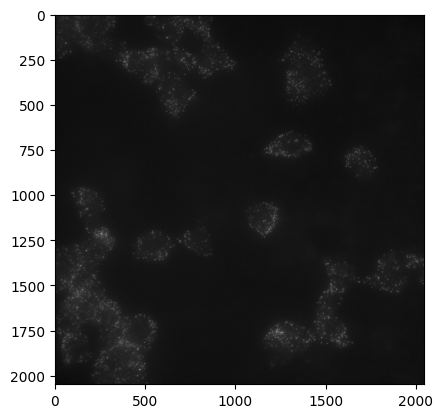

In [77]:
images = sample_dict["s001"]["647"]
print(img.dtype, img.min(), img.max())
plt.figure()
plt.imshow(images, cmap='gray')
plt.show()

In [78]:
filtered_masks, valid_indices = fish.get_masks_from_mat(filename, "Track251009COLA01")
print(valid_indices)
filtered_images = np.array([images[i] for i in valid_indices]) # filters out the images that don't have masks


[0, 1, 2, 3, 4]


In [41]:
filtered_images.shape

(5, 2048, 2048)

In [42]:
filtered_masks.shape

(5, 2048, 2048)

TypeError: Invalid shape (2048,) for image data

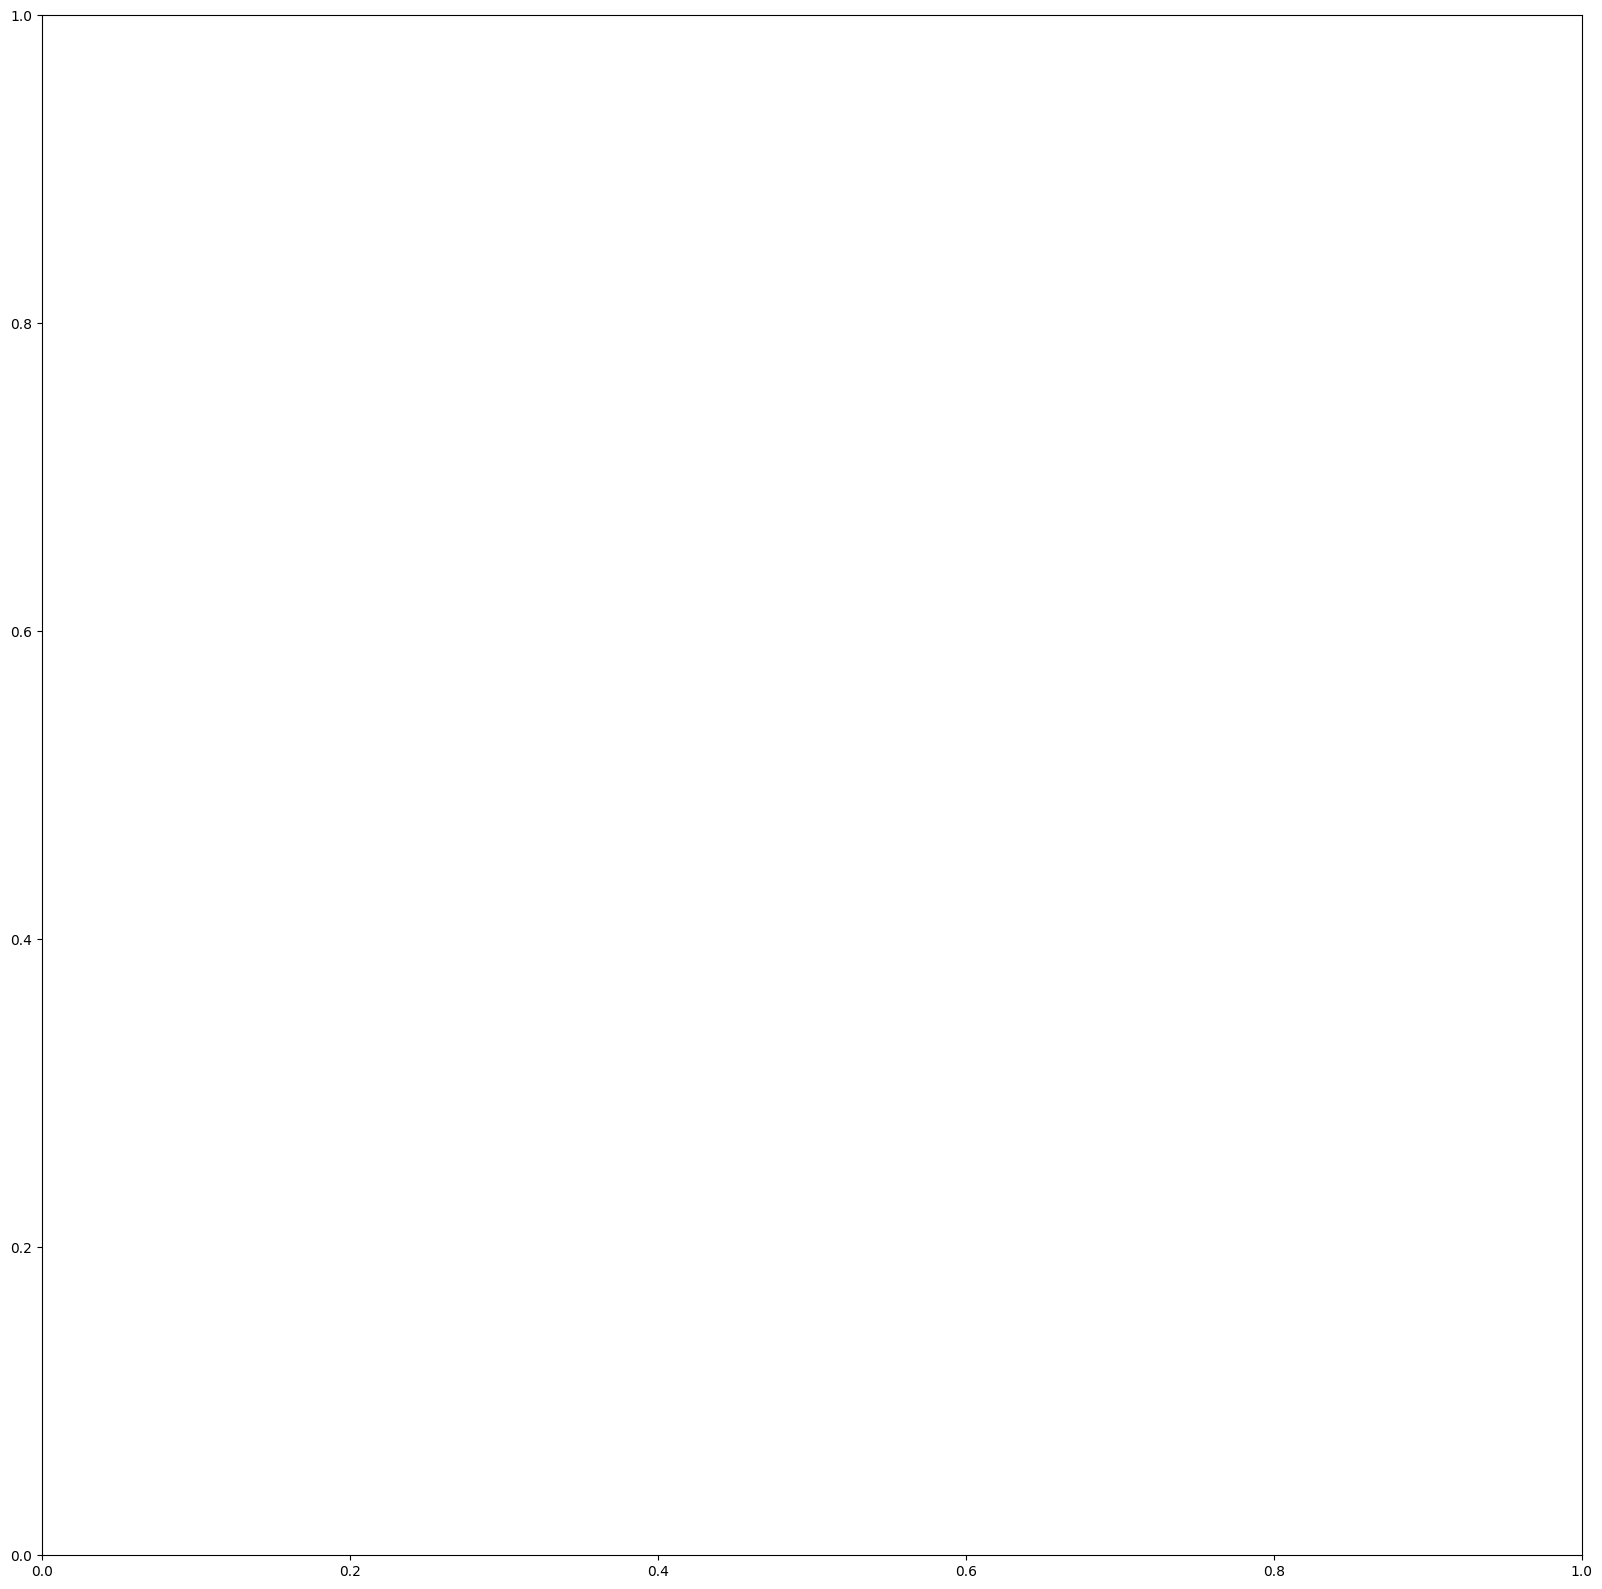

In [79]:
fish.plot_mask_on_image(filtered_images[0], filtered_masks[0], 'Example 1')

In [9]:
def rgb_to_grayscale(images):
    # Initialize an empty array to hold the grayscale images
    grayscale_imgs = np.zeros((images.shape[0], images.shape[1], images.shape[2]), dtype=np.uint8)
    
    for i in range(images.shape[0]):
        # Convert each RGB image to a PIL Image, then convert to grayscale
        pil_img = Image.fromarray(images[i].astype('uint8'), 'RGB')
        gray_img = pil_img.convert('L')
        # Convert back to numpy array and store in the grayscale_imgs array
        grayscale_imgs[i] = np.array(gray_img)

    return grayscale_imgs

# Convert your filtered images
grayscale_images = filtered_images
grayscale_images.shape

(50, 2048, 2048)

In [10]:
#Desired patch size for smaller images and step size.
patch_size = 256
step = 255

all_img_patches = []
for img in range(grayscale_images.shape[0]):
    large_image = grayscale_images[img]
    patches_img = patchify(large_image, (patch_size, patch_size), step=step)  #Step=256 for 256 patches means no overlap

    for i in range(patches_img.shape[0]):
        for j in range(patches_img.shape[1]):

            single_patch_img = patches_img[i,j,:,:]
            all_img_patches.append(single_patch_img)

images = np.array(all_img_patches)

#Let us do the same for masks
all_mask_patches = []
for img in range(filtered_masks.shape[0]):
    large_mask = filtered_masks[img]
    patches_mask = patchify(large_mask, (patch_size, patch_size), step=step)  #Step=256 for 256 patches means no overlap

    for i in range(patches_mask.shape[0]):
        for j in range(patches_mask.shape[1]):

            single_patch_mask = patches_mask[i,j,:,:]
            single_patch_mask = (single_patch_mask).astype(np.uint8)
            all_mask_patches.append(single_patch_mask)

masks = np.array(all_mask_patches)

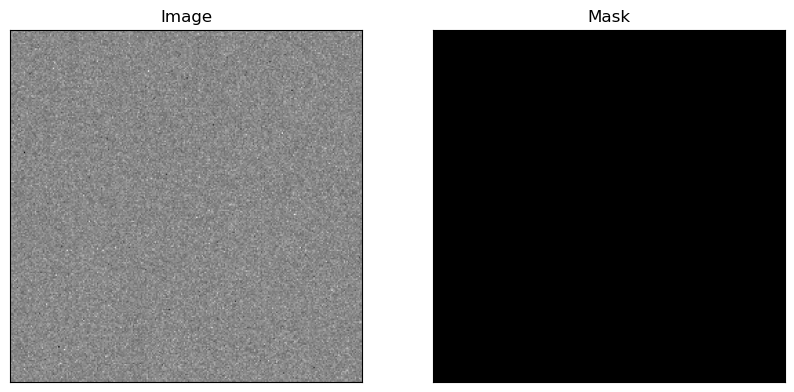

In [11]:
img_num = random.randint(0, filtered_images.shape[0]-1)
example_image = images[img_num]
example_mask = masks[img_num]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot the first image on the left
axes[0].imshow(np.array(example_image), cmap='gray')  # Assuming the first image is grayscale
axes[0].set_title("Image")

# Plot the second image on the right
axes[1].imshow(example_mask, cmap='gray')  # Assuming the second image is grayscale
axes[1].set_title("Mask")

# Hide axis ticks and labels
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

# Display the images side by side
plt.show()

In [12]:
images.shape

(3200, 256, 256)

In [13]:
masks.shape

(3200, 256, 256)

In [14]:
# Create a list to store the indices of non-empty masks
valid_indices = [i for i, mask in enumerate(masks) if mask.max() != 0]
# Filter the image and mask arrays to keep only the non-empty pairs
images_ready = images[valid_indices]
masks_ready = masks[valid_indices]
print("Image shape:", images_ready.shape)  # e.g., (num_frames, height, width, num_channels)
print("Mask shape:", masks_ready.shape)

Image shape: (2851, 256, 256)
Mask shape: (2851, 256, 256)


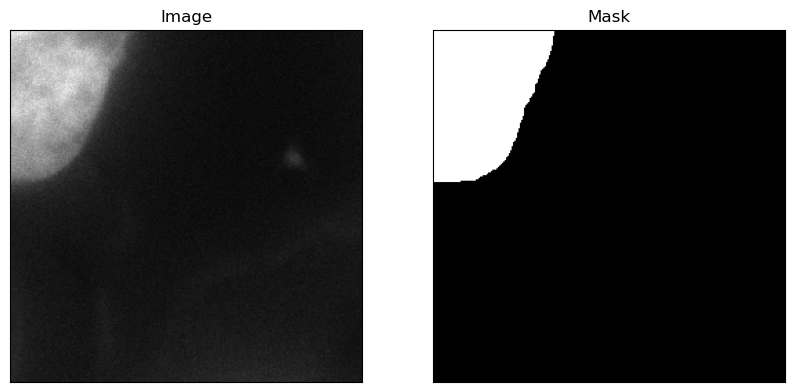

In [15]:
img_num = random.randint(0, filtered_images.shape[0]-1)
example_image = images_ready[img_num]
example_mask = masks_ready[img_num]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot the first image on the left
axes[0].imshow(np.array(example_image), cmap='gray')  # Assuming the first image is grayscale
axes[0].set_title("Image")

# Plot the second image on the right
axes[1].imshow(example_mask, cmap='gray')  # Assuming the second image is grayscale
axes[1].set_title("Mask")

# Hide axis ticks and labels
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

# Display the images side by side
plt.show()

In [16]:
images_ready.shape

(2851, 256, 256)

In [17]:
rgb_images_ready = grayscale_to_rgb(images_ready)

In [18]:
rgb_images_ready.shape

(2851, 256, 256, 3)

In [19]:
rgb_images_ready[0][0][0]

array([34, 34, 34], dtype=uint8)

In [20]:
# Convert the NumPy arrays to Pillow images, storing them in a dictionary
dataset_dict = {
    "image": [Image.fromarray(img.astype(np.uint8)) for img in rgb_images_ready],
    "label": [Image.fromarray(mask) for mask in masks_ready],
}

# Create the dataset using the datasets.Dataset class
dataset = Dataset.from_dict(dataset_dict)

In [21]:
dataset

Dataset({
    features: ['image', 'label'],
    num_rows: 2851
})

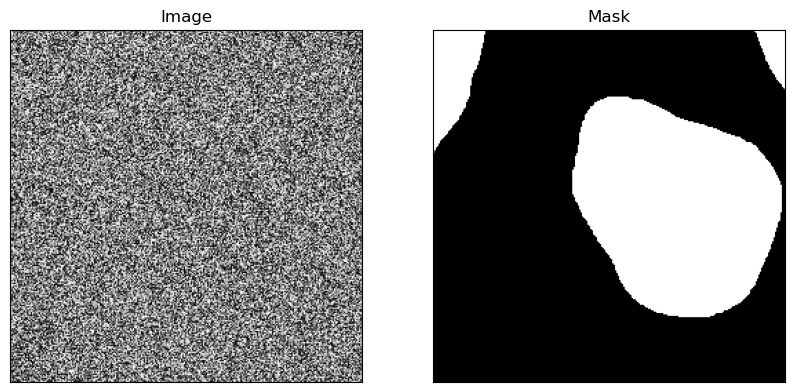

In [22]:
img_num = random.randint(0, filtered_images.shape[0]-1)
example_image = dataset[img_num]["image"]
example_mask = dataset[img_num]["label"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot the first image on the left
axes[0].imshow(np.array(example_image))  # Assuming the first image is grayscale
axes[0].set_title("Image")

# Plot the second image on the right
axes[1].imshow(example_mask, cmap='gray')  # Assuming the second image is grayscale
axes[1].set_title("Mask")

# Hide axis ticks and labels
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

# Display the images side by side
plt.show()

In [23]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# "facebook/sam-vit-huge" is equivalent to "ViT-H SAM model"
model = SamModel.from_pretrained("facebook/sam-vit-huge").to(device)
processor = SamProcessor.from_pretrained("facebook/sam-vit-huge")

In [24]:
print(len(dataset))
print(dataset[0])
print(dataset.dataset_size)

2851
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=256x256 at 0x20E5ACB0F90>, 'label': <PIL.PngImagePlugin.PngImageFile image mode=L size=256x256 at 0x20E5ACB1150>}
None


In [25]:
train_dataset = ppf.SAMDataset(dataset=dataset, processor=processor)

In [26]:
train_dataset

In [27]:
example = train_dataset[0]
for k,v in example.items():
  print(k,v.shape)

[18, 34, 256, 194]
pixel_values torch.Size([3, 1024, 1024])
original_sizes torch.Size([2])
reshaped_input_sizes torch.Size([2])
input_boxes torch.Size([1, 4])
ground_truth_mask (256, 256)


In [28]:
train_dataloader = DataLoader(train_dataset, batch_size=2, shuffle=True)

In [29]:
batch = next(iter(train_dataloader))
for k,v in batch.items():
  print(k,v.shape)

[185, 0, 256, 225]
[0, 0, 256, 256]
pixel_values torch.Size([2, 3, 1024, 1024])
original_sizes torch.Size([2, 2])
reshaped_input_sizes torch.Size([2, 2])
input_boxes torch.Size([2, 1, 4])
ground_truth_mask torch.Size([2, 256, 256])


In [30]:
batch["ground_truth_mask"].shape

torch.Size([2, 256, 256])

In [31]:
from transformers import SamModel 

model = SamModel.from_pretrained("facebook/sam-vit-base")

# make sure we only compute gradients for mask decoder
for name, param in model.named_parameters():
  if name.startswith("vision_encoder") or name.startswith("prompt_encoder"):
    param.requires_grad_(False)

In [32]:
from torch.optim import Adam
import monai

# Note: Hyperparameter tuning could improve performance here
optimizer = Adam(model.mask_decoder.parameters(), lr=1e-5, weight_decay=0)

seg_loss = monai.losses.DiceCELoss(sigmoid=True, squared_pred=True, reduction='mean')

In [36]:
from tqdm import tqdm
from statistics import mean
import torch
from torch.nn.functional import threshold, normalize

num_epochs = 100

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

model.train()
for epoch in range(num_epochs):
    epoch_losses = []
    for batch in tqdm(train_dataloader):
      # forward pass
      outputs = model(
         pixel_values=batch["pixel_values"].to(device),
         input_boxes=batch["input_boxes"].to(device),
         multimask_output=False
      )

      # compute loss
      predicted_masks = outputs.pred_masks.squeeze(1)
      ground_truth_masks = batch["ground_truth_mask"].float().to(device)
      loss = seg_loss(predicted_masks, ground_truth_masks.unsqueeze(1))

      # backward pass (compute gradients of parameters w.r.t. loss)
      optimizer.zero_grad()
      loss.backward()

      # optimize
      optimizer.step()
      epoch_losses.append(loss.item())

  0%|          | 0/1426 [00:00<?, ?it/s]

[0, 0, 256, 235]
[0, 15, 256, 256]


  0%|          | 1/1426 [00:00<11:36,  2.05it/s]

[0, 0, 256, 256]
[69, 0, 239, 233]


  0%|          | 2/1426 [00:00<10:40,  2.22it/s]

...

  2%|▏         | 26/1426 [00:11<09:59,  2.34it/s]

[0, 0, 256, 217]
[0, 100, 177, 211]


  2%|▏         | 27/1426 [00:11<10:01,  2.33it/s]


[171, 0, 256, 121]


KeyboardInterrupt: 